# Exploracion de la API del BCRP

Este notebook explora los principales indicadores macroeconomicos del Peru obtenidos del **Banco Central de Reserva del Peru (BCRP)**.

**Indicadores analizados:**
- Tipo de cambio USD/PEN
- Tasa de referencia del BCRP
- Inflacion interanual
- Variacion del PBI
- Reservas internacionales netas

**Periodo:** Enero 2015 - Diciembre 2024 (datos mensuales)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas cargadas correctamente')

Bibliotecas cargadas correctamente


## 1. Generacion de datos simulados

Generamos datos macroeconomicos realistas basados en las tendencias historicas del Peru (2015-2024).

In [2]:
np.random.seed(42)
dates = pd.date_range('2015-01-01', '2024-12-01', freq='MS')
n = len(dates)

# Tipo de cambio USD/PEN con spike COVID
base_tc = np.linspace(3.18, 3.75, n)
covid_mask = (dates >= '2020-03-01') & (dates <= '2021-06-01')
spike = np.zeros(n)
for i, d in enumerate(dates):
    if covid_mask[i]:
        months_in = (d - pd.Timestamp('2020-03-01')).days / 30
        spike[i] = 0.35 * np.sin(np.pi * months_in / 16)
base_tc += spike
tc = base_tc + np.random.normal(0, 0.03, n)
tc = np.clip(tc, 3.0, 4.15)

# Tasa de referencia BCRP
tasa_ref = np.zeros(n)
for i, d in enumerate(dates):
    y = d.year + d.month / 12
    if y < 2016.5: tasa_ref[i] = 3.50
    elif y < 2017.5: tasa_ref[i] = 4.25 - (y - 2016.5) * 1.5
    elif y < 2019.0: tasa_ref[i] = 2.75
    elif y < 2020.0: tasa_ref[i] = 2.50 + (y - 2019.0) * 0.25
    elif y < 2020.4: tasa_ref[i] = 2.25 - (y - 2020.0) * 5.0
    elif y < 2021.5: tasa_ref[i] = 0.25
    elif y < 2022.0: tasa_ref[i] = 0.25 + (y - 2021.5) * 5.0
    elif y < 2023.0: tasa_ref[i] = 3.0 + (y - 2022.0) * 4.75
    elif y < 2023.8: tasa_ref[i] = 7.75
    else: tasa_ref[i] = 7.75 - (y - 2023.8) * 3.5
tasa_ref = np.clip(tasa_ref, 0.25, 7.75)

# Inflacion interanual
inflacion = np.zeros(n)
for i, d in enumerate(dates):
    y = d.year + d.month / 12
    if y < 2020.0: inflacion[i] = 2.5 + 0.8 * np.sin(2 * np.pi * (y - 2015) / 3)
    elif y < 2021.0: inflacion[i] = 1.8
    elif y < 2022.0: inflacion[i] = 1.8 + (y - 2021.0) * 6.7
    elif y < 2022.7: inflacion[i] = 8.5
    elif y < 2024.0: inflacion[i] = 8.5 - (y - 2022.7) * 4.6
    else: inflacion[i] = 2.8
inflacion += np.random.normal(0, 0.15, n)
inflacion = np.clip(inflacion, 0.5, 9.0)

# Indicadores adicionales
pbi_var = 0.03 * tc + 0.5 * tasa_ref + np.random.normal(0, 0.8, n)
reservas = 65 - 2 * tc + 0.3 * tasa_ref + np.random.normal(0, 1.5, n)

df = pd.DataFrame({
    'fecha': dates,
    'tipo_cambio': np.round(tc, 4),
    'tasa_referencia': np.round(tasa_ref, 2),
    'inflacion': np.round(inflacion, 2),
    'var_pbi': np.round(pbi_var, 2),
    'reservas_intl_bUSD': np.round(reservas, 2),
})

print(f'Dataset generado: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'Periodo: {df["fecha"].min().strftime("%Y-%m")} a {df["fecha"].max().strftime("%Y-%m")}')
df.head(10)

Dataset generado: 120 registros, 6 columnas
Periodo: 2015-01 a 2024-12


fecha,tipo_cambio,tasa_referencia,inflacion,var_pbi,reservas_intl_bUSD
2015-01-01,3.1949,3.5,2.76,1.21,60.44
2015-02-01,3.1806,3.5,2.64,1.75,61.99
2015-03-01,3.2090,3.5,3.11,2.25,59.47
2015-04-01,3.2401,3.5,2.80,2.54,60.17
2015-05-01,3.1921,3.5,3.20,0.89,60.70
2015-06-01,3.1969,3.5,3.52,1.58,59.05
2015-07-01,3.2561,3.5,3.10,1.47,59.87
2015-08-01,3.2366,3.5,3.20,1.32,59.60
2015-09-01,3.2042,3.5,3.31,3.26,59.79
2015-10-01,3.2394,3.5,3.21,2.17,58.41


### Estadisticas descriptivas

In [3]:
df.describe()

,fecha,tipo_cambio,tasa_referencia,inflacion,var_pbi,reservas_intl_bUSD
count,120,120.000000,120.000000,120.000000,120.000000,120.000000
mean,2019-12-16 10:48:00,3.491860,3.539083,3.605750,1.882417,59.170500
min,2015-01-01 00:00:00,3.180600,0.250000,1.510000,-0.680000,54.200000
25%,2017-06-23 12:00:00,3.309225,2.615000,2.247500,0.930000,58.335000
50%,2019-12-16 12:00:00,3.468700,3.390000,2.900000,1.665000,59.140000
75%,2022-06-08 12:00:00,3.650000,4.292500,3.540000,2.777500,60.185000
max,2024-12-01 00:00:00,3.907100,7.750000,9.000000,4.570000,63.210000
std,NaN,0.200281,2.132072,2.078895,1.182660,1.743719


## 2. Configuracion visual

Aplicamos un tema claro profesional para todas las visualizaciones.

In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'text.color': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'grid.color': '#e0e0e0',
    'grid.alpha': 0.6,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#cccccc',
    'legend.fontsize': 10,
    'savefig.facecolor': '#ffffff',
})
print('Tema claro aplicado')

Tema claro aplicado


## 3. Tipo de cambio y tasa de referencia

Grafico de doble eje que muestra la relacion entre el tipo de cambio USD/PEN y la tasa de referencia del BCRP.

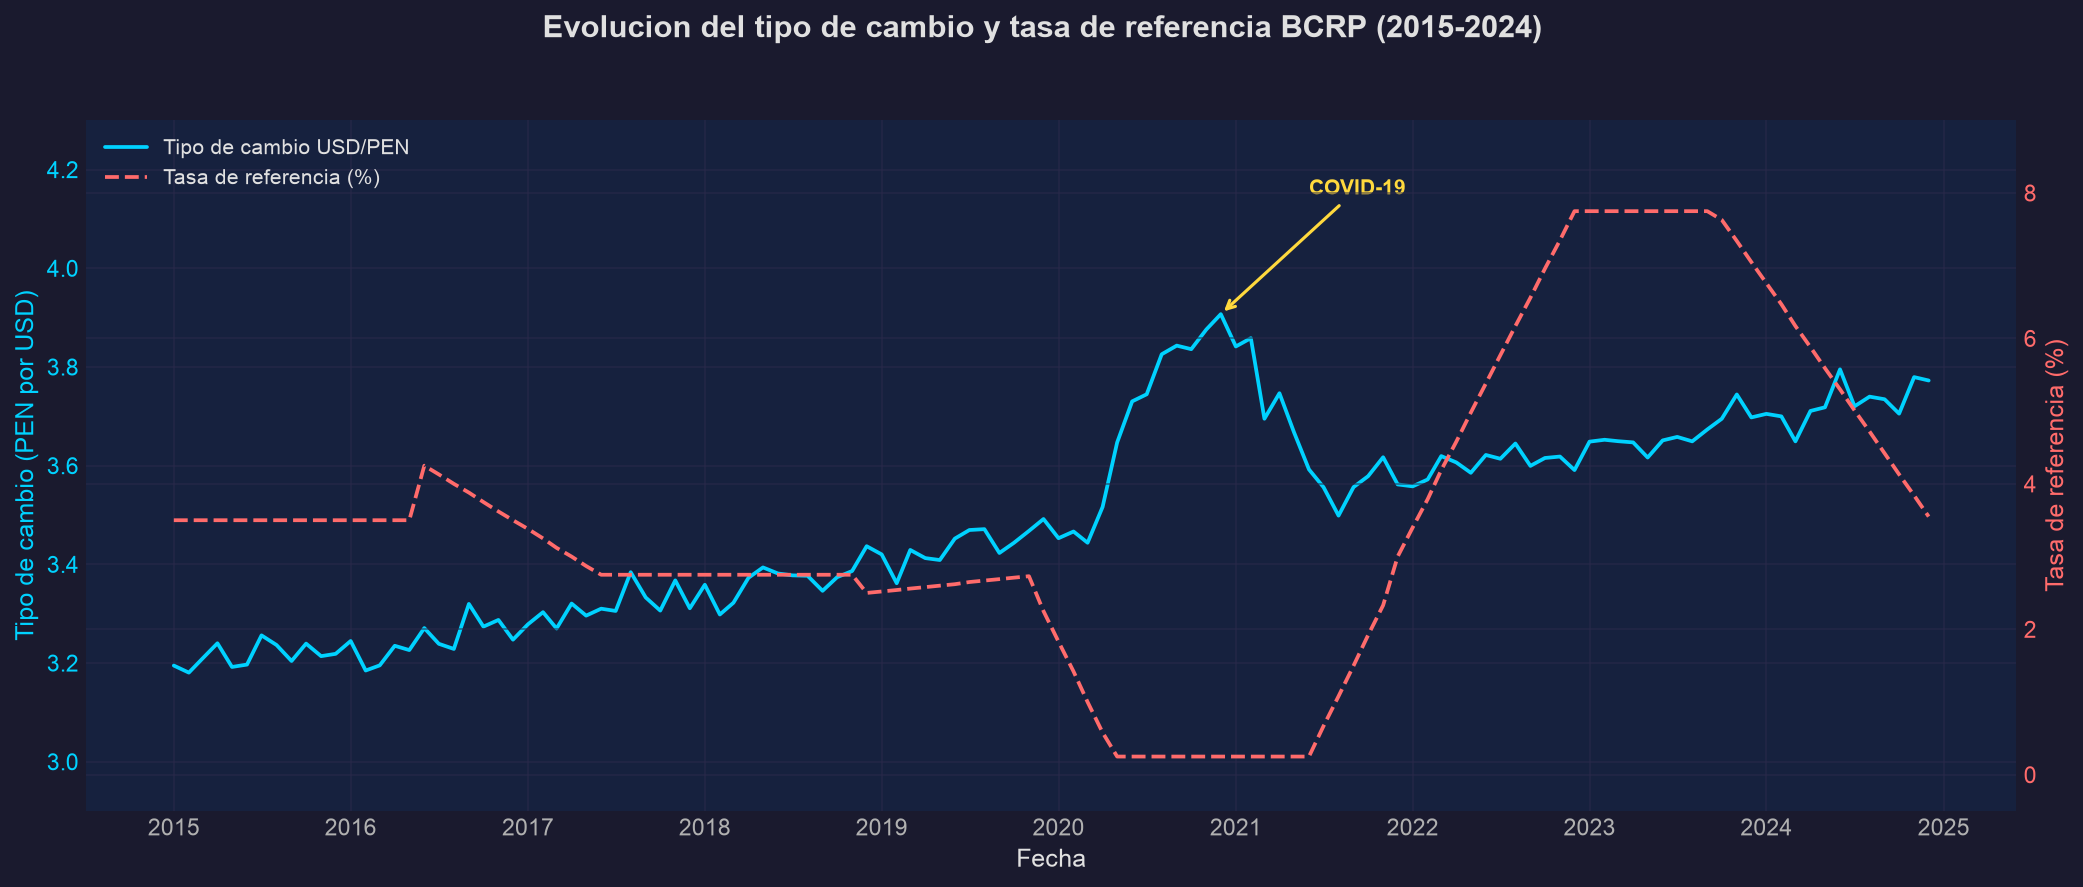

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color_tc = '#00d2ff'
color_tasa = '#ff6b6b'

ax1.plot(df['fecha'], df['tipo_cambio'], color=color_tc, linewidth=1.8,
         label='Tipo de cambio USD/PEN')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Tipo de cambio (PEN por USD)', color=color_tc)
ax1.tick_params(axis='y', labelcolor=color_tc)
ax1.set_ylim(2.9, 4.3)

ax2 = ax1.twinx()
ax2.plot(df['fecha'], df['tasa_referencia'], color=color_tasa, linewidth=1.8,
         linestyle='--', label='Tasa de referencia (%)')
ax2.set_ylabel('Tasa de referencia (%)', color=color_tasa)
ax2.tick_params(axis='y', labelcolor=color_tasa)
ax2.set_ylim(-0.5, 9.0)

# Anotacion COVID-19
covid_mask = (df['fecha'] >= '2020-03-01') & (df['fecha'] <= '2021-06-01')
peak_idx = df.loc[covid_mask, 'tipo_cambio'].idxmax()
ax1.annotate('COVID-19',
    xy=(df['fecha'][peak_idx], df['tipo_cambio'][peak_idx]),
    xytext=(df['fecha'][peak_idx] + pd.DateOffset(months=6), 4.15),
    arrowprops=dict(arrowstyle='->', color='#ffd93d', lw=1.5),
    fontsize=10, color='#ffd93d', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.8)

fig.suptitle('Evolucion del tipo de cambio y tasa de referencia BCRP (2015-2024)',
             fontsize=15, fontweight='bold', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4. Inflacion interanual vs meta BCRP

La banda sombreada representa el rango meta del BCRP (1% - 3%), con centro en 2%.

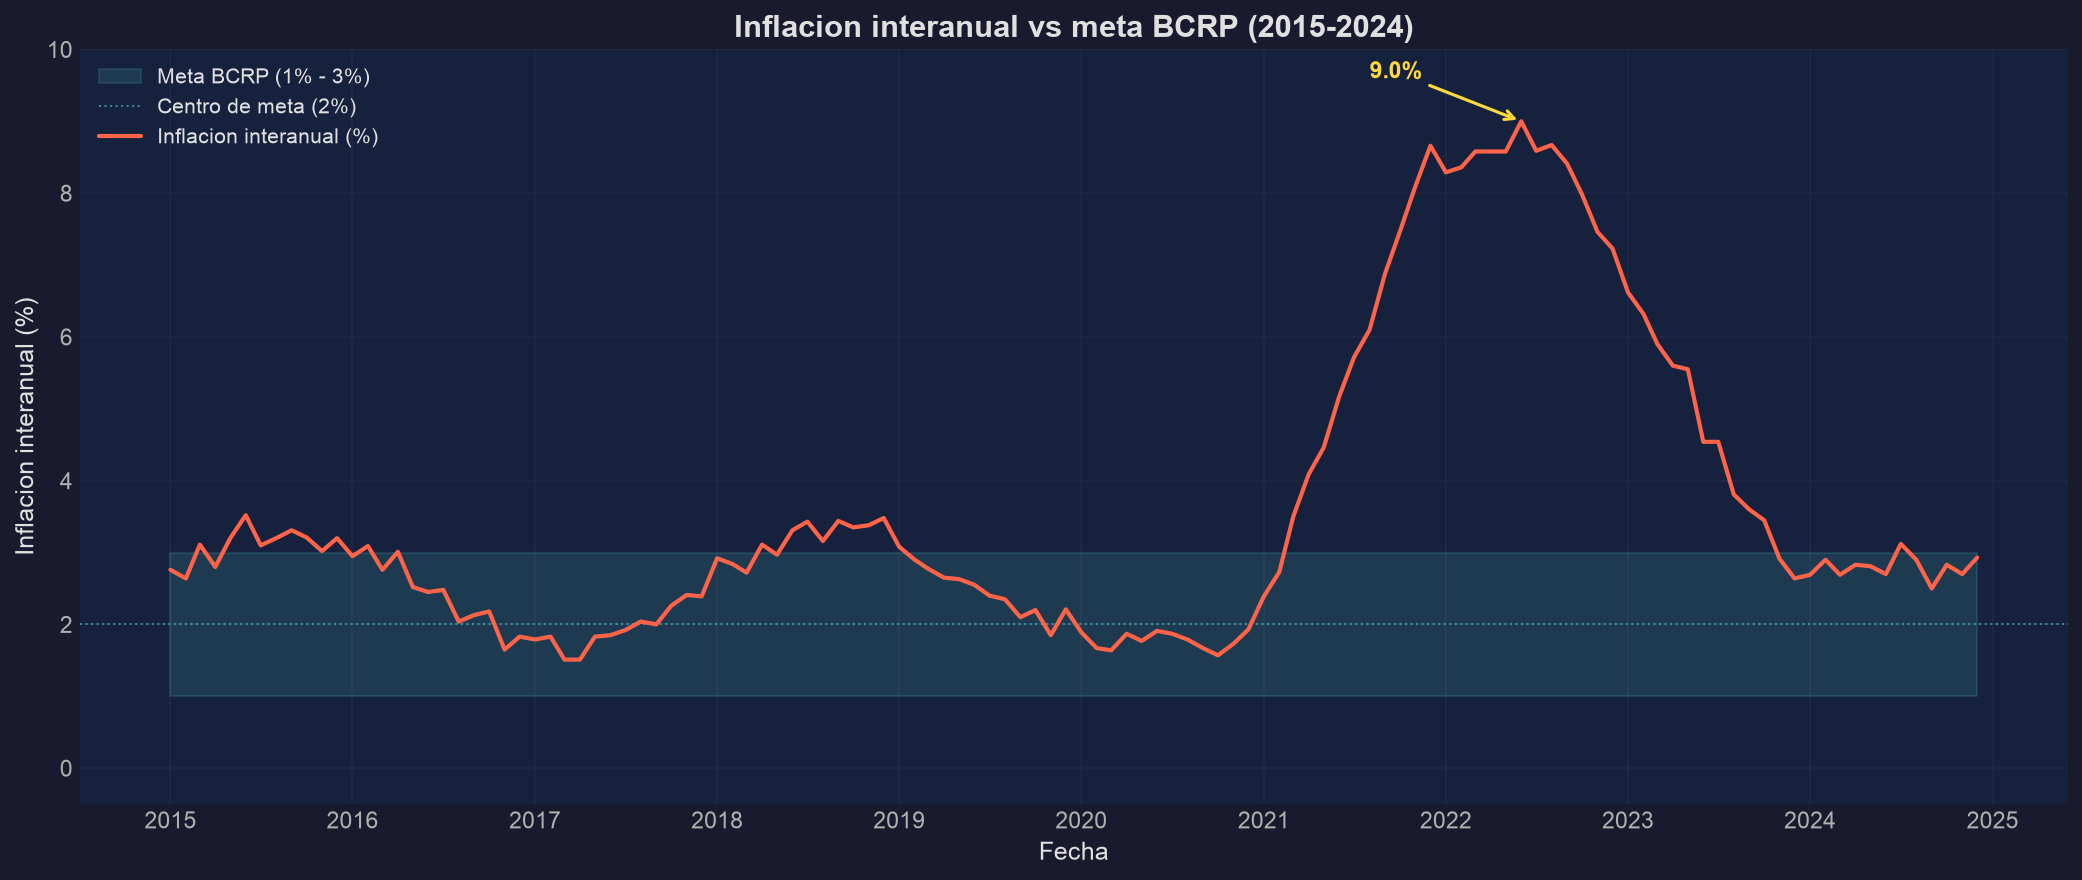

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(df['fecha'], 1, 3, alpha=0.15, color='#4ecdc4',
                label='Meta BCRP (1% - 3%)')
ax.axhline(y=2, color='#4ecdc4', linewidth=1, linestyle=':', alpha=0.6,
           label='Centro de meta (2%)')
ax.plot(df['fecha'], df['inflacion'], color='#ff6348', linewidth=2,
        label='Inflacion interanual (%)')

# Anotacion del pico
peak_idx = df['inflacion'].idxmax()
ax.annotate(f'{df["inflacion"][peak_idx]:.1f}%',
    xy=(df['fecha'][peak_idx], df['inflacion'][peak_idx]),
    xytext=(df['fecha'][peak_idx] - pd.DateOffset(months=10),
            df['inflacion'][peak_idx] + 0.6),
    arrowprops=dict(arrowstyle='->', color='#ffd93d', lw=1.5),
    fontsize=11, color='#ffd93d', fontweight='bold')

ax.set_xlabel('Fecha')
ax.set_ylabel('Inflacion interanual (%)')
ax.set_ylim(-0.5, 10)
ax.legend(loc='upper left', framealpha=0.8)
ax.set_title('Inflacion interanual vs meta BCRP (2015-2024)',
             fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Correlacion entre indicadores

Matriz de correlacion de Pearson entre los principales indicadores macroeconomicos.

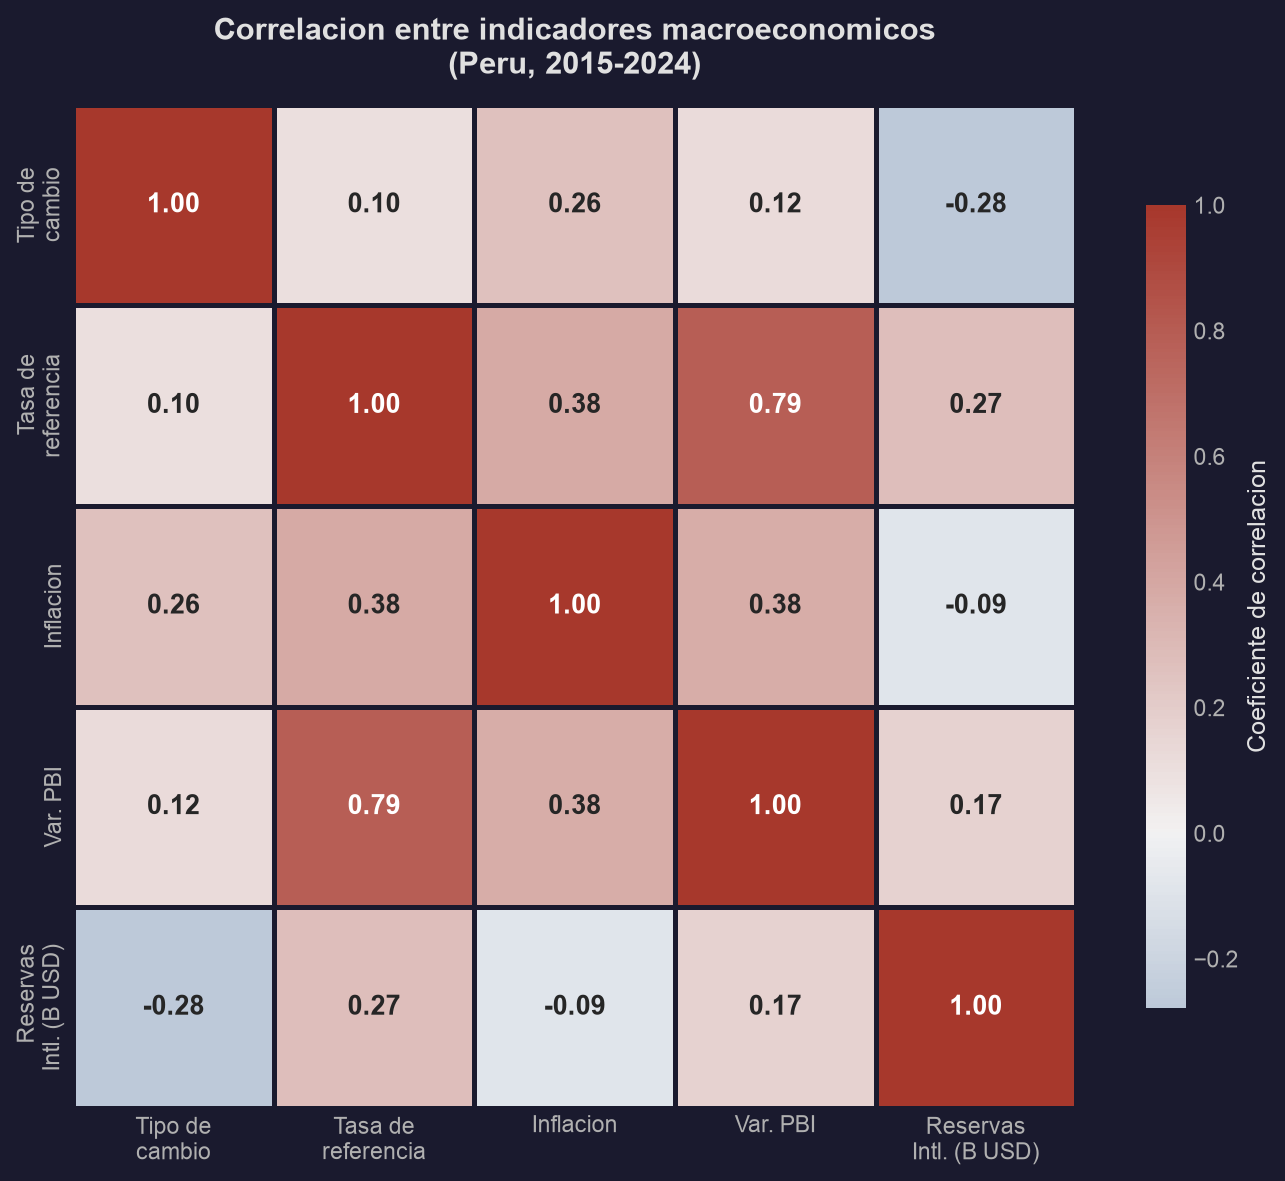

In [7]:
corr_df = df[['tipo_cambio', 'tasa_referencia', 'inflacion',
              'var_pbi', 'reservas_intl_bUSD']].copy()
corr_df.columns = ['Tipo de\ncambio', 'Tasa de\nreferencia',
                   'Inflacion', 'Var. PBI', 'Reservas\nIntl. (B USD)']
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=12, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap, center=0,
            square=True, linewidths=1.5, linecolor='#ffffff',
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlacion'},
            annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)
ax.set_title('Correlacion entre indicadores macroeconomicos\n(Peru, 2015-2024)',
             fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 6. Observaciones preliminares

1. **Tipo de cambio:** Tendencia alcista sostenida con un pico notable durante la pandemia COVID-19 (2020-2021).
2. **Tasa de referencia:** El BCRP redujo agresivamente la tasa a 0.25% durante la pandemia, para luego elevarla a 7.75% en respuesta al brote inflacionario de 2022-2023.
3. **Inflacion:** Se mantuvo cerca de la meta (1%-3%) hasta 2021. El choque de oferta post-pandemia la llevo a niveles cercanos al 8.5% en 2022.
4. **Correlaciones:** La tasa de referencia y la inflacion muestran alta correlacion positiva, reflejando la politica monetaria reactiva del BCRP.

---
*Notebook generado con datos simulados para fines exploratorios.*